In [2]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [34]:
df=pd.read_csv("C:\\Users\\dhruv\\Downloads\\archive (2)\\retail_sales_dataset.csv")

In [36]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [38]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [40]:
stats_summary = {
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Std Dev': df.std(numeric_only=True)
}

summary_df = pd.DataFrame(stats_summary)
print(summary_df)

                   Mean  Median  Mode     Std Dev
Transaction ID  500.500   500.5   1.0  288.819436
Age              41.392    42.0  43.0   13.681430
Quantity          2.514     3.0   4.0    1.132734
Price per Unit  179.890    50.0  50.0  189.681356
Total Amount    456.000   135.0  50.0  559.997632


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [44]:
df.shape

(1000, 9)

In [46]:
#Time Series Analysis

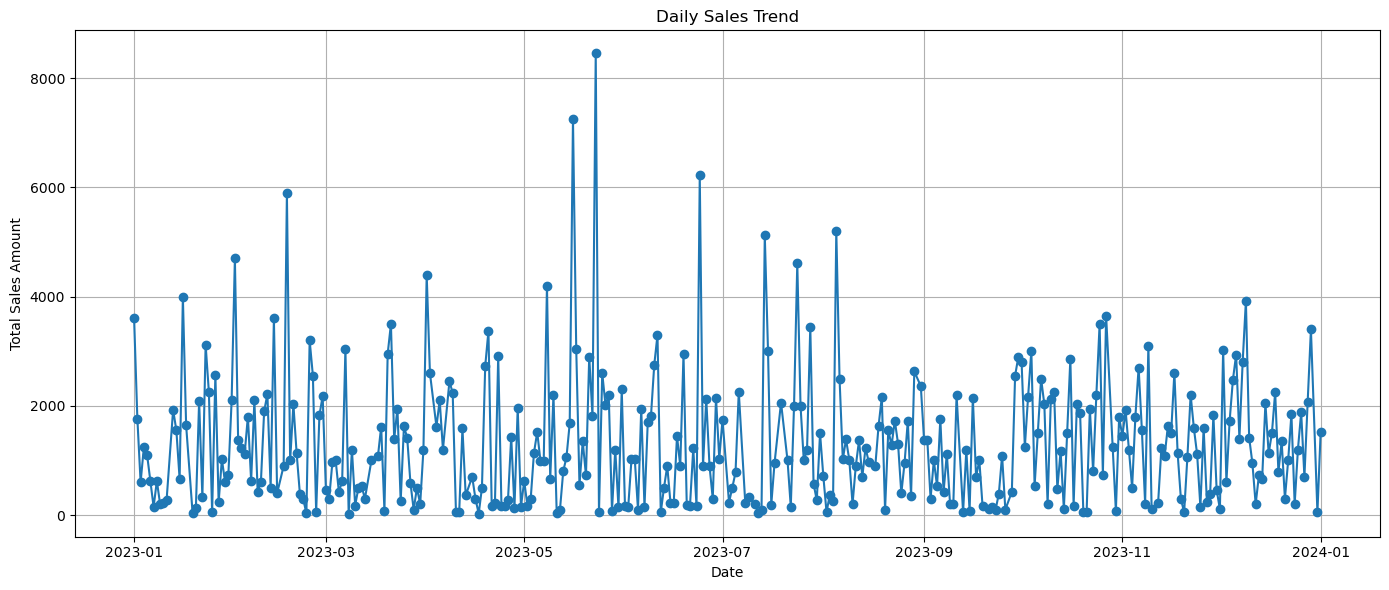

In [48]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Group by date and sum the 'Total Amount' to get daily sales
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()

# Set the 'Date' as the index for time series analysis
daily_sales.set_index('Date', inplace=True)

# Plot the sales trend
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(daily_sales, marker='o', linestyle='-')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.tight_layout()
plt.show()



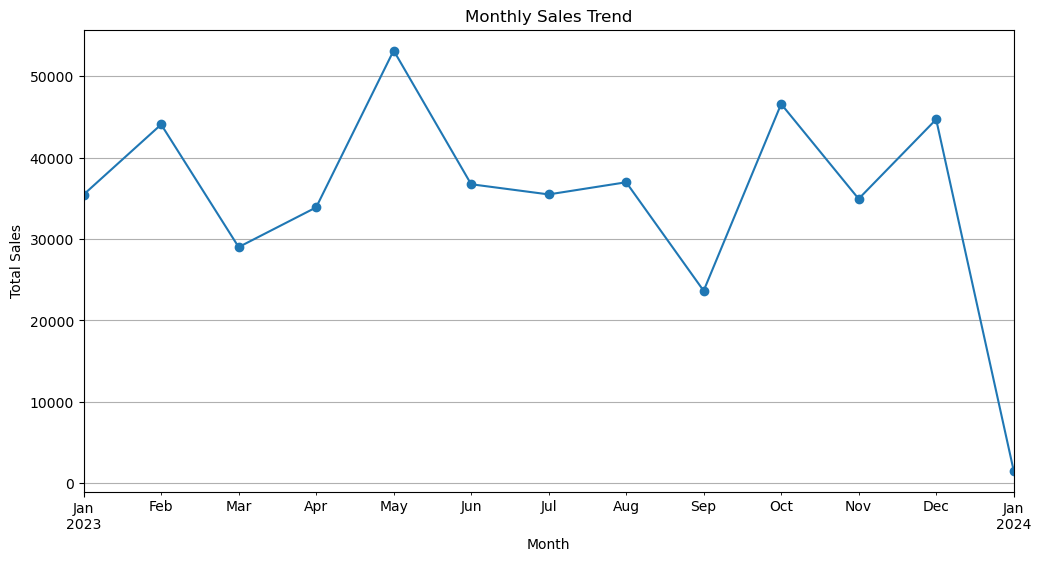

In [50]:
# Monthly sales total
df.set_index('Date', inplace=True)
monthly_sales = df['Total Amount'].resample('ME').sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

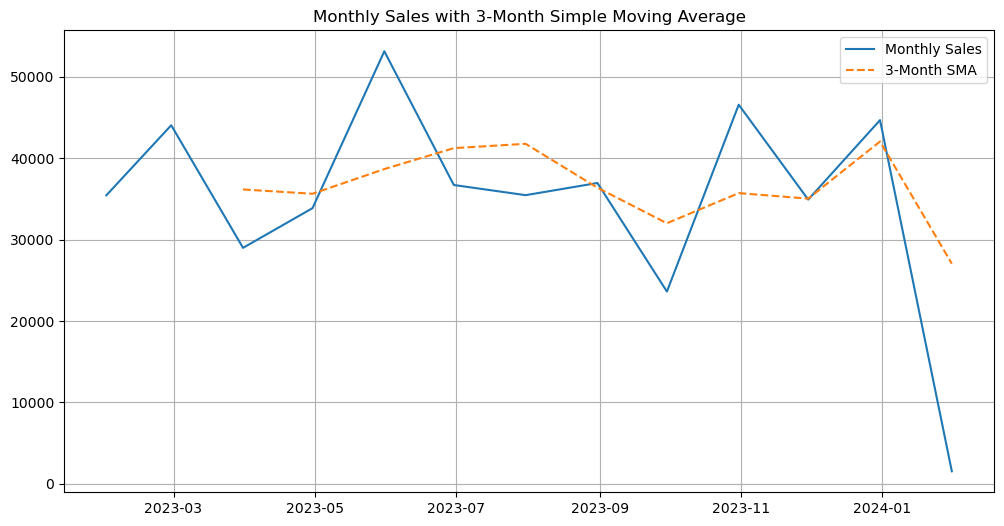

In [52]:
monthly_sales_df = monthly_sales.to_frame(name='Sales')
monthly_sales_df['SMA_3'] = monthly_sales_df['Sales'].rolling(window=3).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_df['Sales'], label='Monthly Sales')
plt.plot(monthly_sales_df['SMA_3'], label='3-Month SMA', linestyle='--')
plt.title('Monthly Sales with 3-Month Simple Moving Average')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#EDA

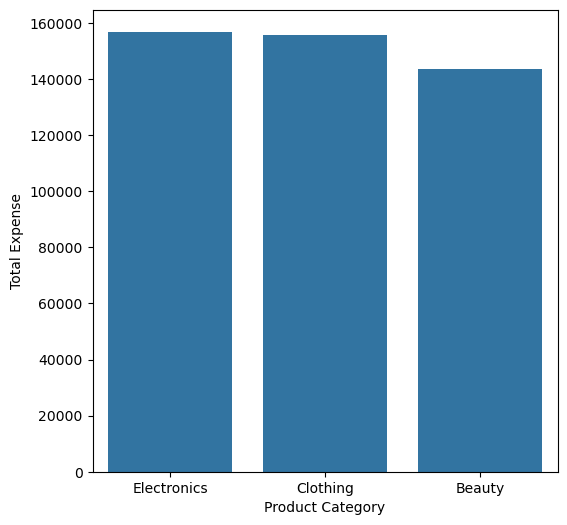

In [208]:
#Total Amount per Product Category
group1 = df.groupby(['Product Category'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount',ascending=False)

plt.figure(figsize=(6,6))
sns.barplot(data=group1, x='Product Category', y='Total Amount')
plt.xlabel('Product Category')
plt.ylabel('Total Expense')
plt.show()

In [210]:
#Disaggregarting the Date Column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['Days'] = df['Date'].dt.day_name()
df['MonthDate'] = df['Date'].dt.day
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,2023,Friday,13,40-49
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29


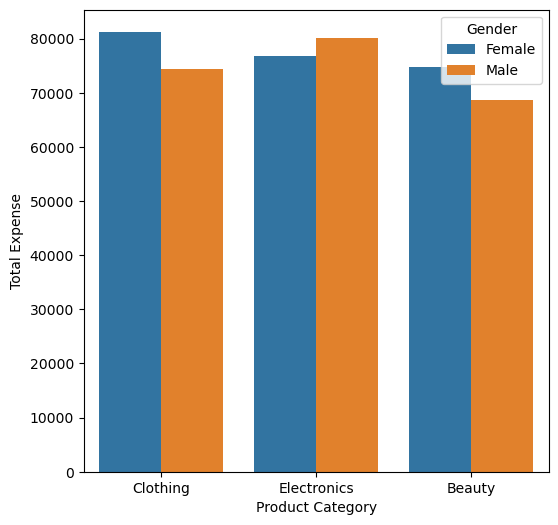

In [212]:
#Gender wise Total Amount for each Product Category
group2 = df.groupby(['Product Category','Gender'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount',ascending=False)

plt.figure(figsize=(6,6))
sns.barplot(data=group2,x='Product Category',y='Total Amount',hue='Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Expense')
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_12428\173916841.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby(['Days','Product Category'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount',ascending=False)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_12428\173916841.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group4 = df.groupby(['Month','Product Category'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount',ascending=False)


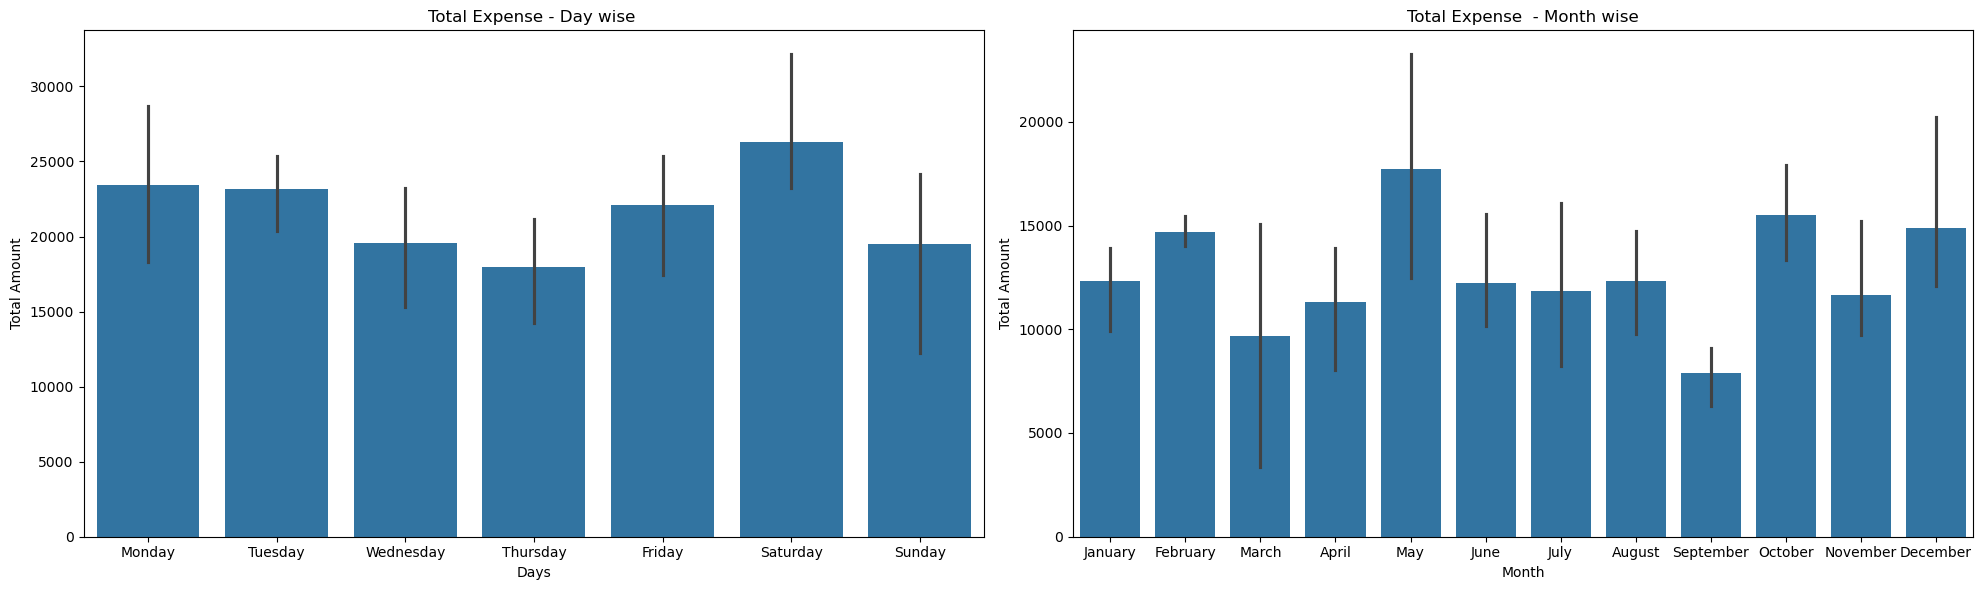

In [213]:
#Check Total Amount distributed for each month and day of the week 
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['Month'] = pd.Categorical(df['Month'],categories=month_order,ordered=True) #Bring months and days in chronological order

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Days'] = pd.Categorical(df['Days'],categories=day_order,ordered=True)

group3 = df.groupby(['Days','Product Category'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount',ascending=False)
group4 = df.groupby(['Month','Product Category'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount',ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (20,6))

sns.barplot(data=group3, x='Days', y='Total Amount',ax=axes[0])
axes[0].set_title('Total Expense - Day wise ')

sns.barplot(data=group4, x='Month', y='Total Amount',ax=axes[1])
axes[1].set_title('Total Expense  - Month wise')
plt.tight_layout()
plt.show()

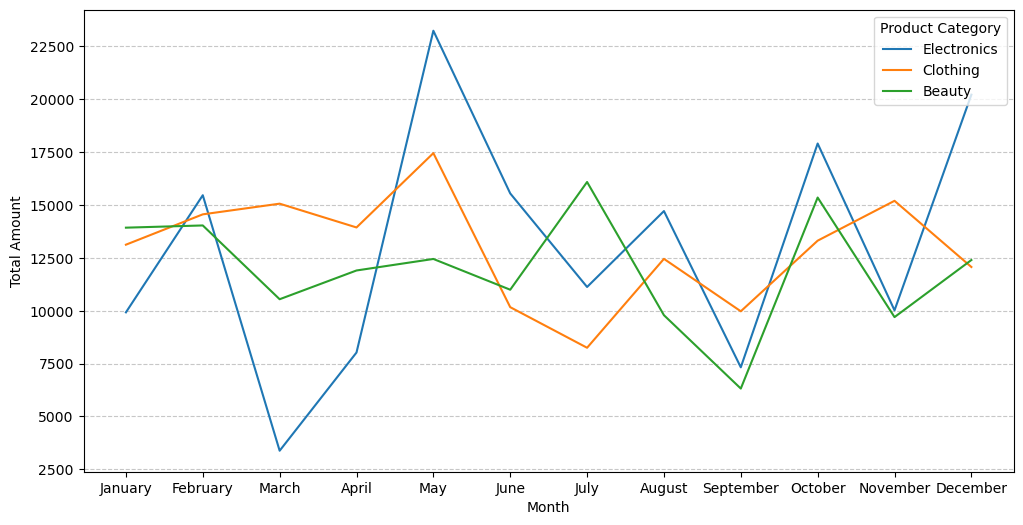

In [215]:
#Check how the Amount for each Product Category has changed with time
plt.figure(figsize=(12,6))
sns.lineplot(data=group4, y='Total Amount',x='Month',hue='Product Category')
plt.title='Monthly Sales by Product'
plt.legend(title='Product Category', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

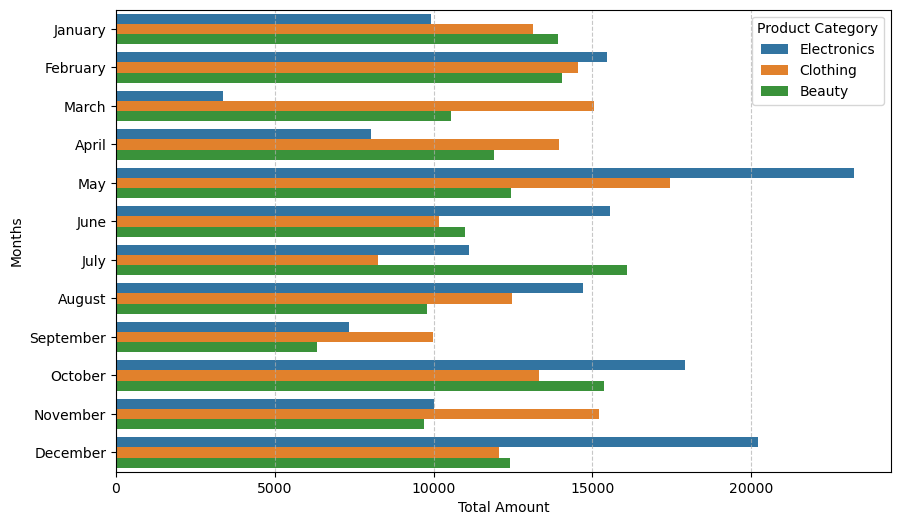

In [216]:
#Check the Category wise Amount for each month
plt.figure(figsize=(10,6))
sns.barplot(data=group4, x='Total Amount',y='Month',hue='Product Category')
plt.xlabel('Total Amount')
plt.ylabel('Months')
plt.legend(title='Product Category', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

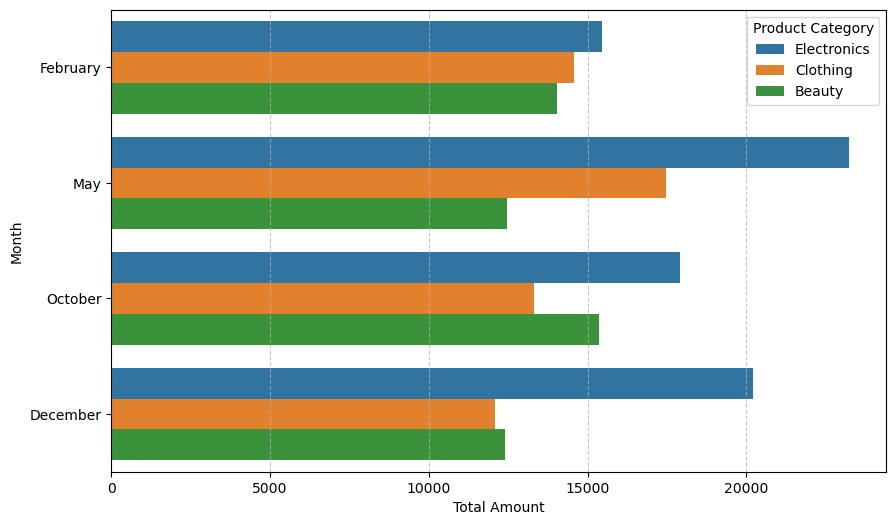

In [217]:
#Exploring: how can we futher zoom-in and see the trends for specific months

filtered_month = ['February','May','October','December']
filtered_group4 = group4[group4['Month'].isin(filtered_month)].copy()

#remove empty months from the chart
filtered_group4['Month'] = pd.Categorical(filtered_group4['Month'], categories=filtered_month, ordered=True) 

plt.figure(figsize=(10,6))
sns.barplot(data=filtered_group4,x='Total Amount',y='Month',hue='Product Category',orient='h')
plt.xlabel('Total Amount')
plt.ylabel('Month')
plt.legend(title='Product Category', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [218]:
#Creating a new variable to capture the age groups
bins=[18,30,40,50,60,70]
label = ['18-29','30-39','40-49','50-59','60+']
df['age_group'] = pd.cut(df['Age'],labels=label,bins=bins)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,2023,Friday,13,40-49
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29


C:\Users\dhruv\AppData\Local\Temp\ipykernel_12428\1477369268.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group5 = df.groupby(['age_group','Gender'])['Total Amount'].sum().reset_index()


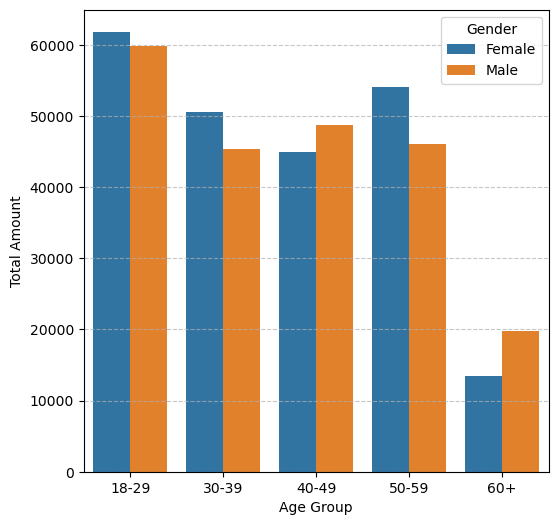

In [219]:
#Check the gender-wise amount spent by people of each age group

group5 = df.groupby(['age_group','Gender'])['Total Amount'].sum().reset_index()

plt.figure(figsize=(6,6))
sns.barplot(data=group5,x='age_group',y='Total Amount',hue='Gender')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.legend(title='Gender', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_12428\4130647346.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group6=df.groupby(['age_group','Product Category'])['Total Amount'].sum().reset_index()


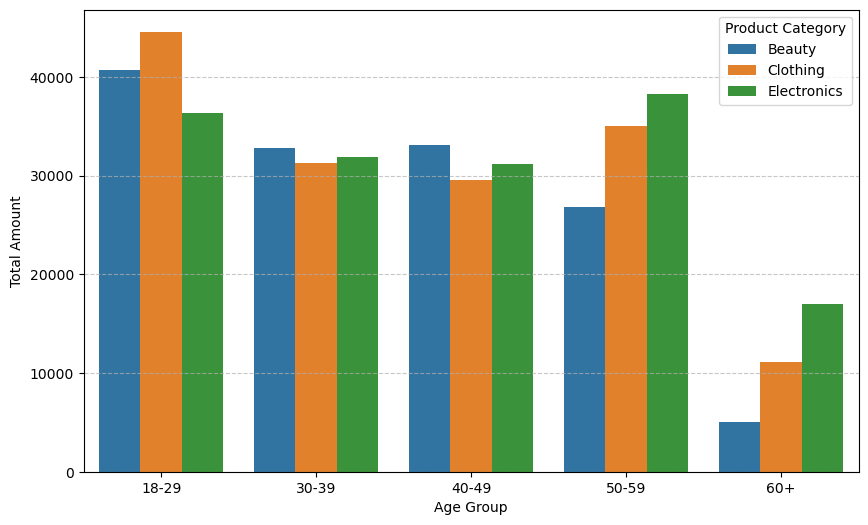

In [221]:
#Product wise expenditure in each age-group

group6=df.groupby(['age_group','Product Category'])['Total Amount'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=group6,x='age_group',y='Total Amount',hue='Product Category')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.legend(title='Product Category', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_12428\638747963.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group7=df.groupby(['age_group', 'Product Category', 'Gender'])['Total Amount'].sum().reset_index()


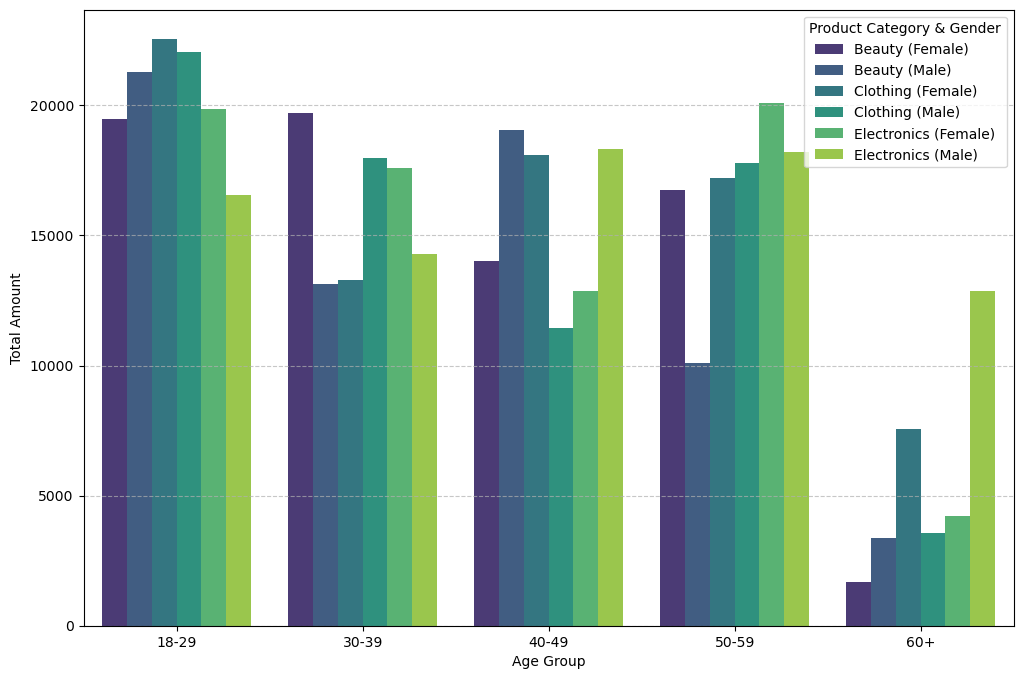

In [222]:
#Combining the above 2 charts: Where are males & females in each age-group spending the most

group7=df.groupby(['age_group', 'Product Category', 'Gender'])['Total Amount'].sum().reset_index()
group7['Product_Gender'] = group7['Product Category'] + ' (' + group7['Gender'] + ')'

plt.figure(figsize=(12, 8))
sns.barplot(data=group7, x='age_group', y='Total Amount', hue='Product_Gender',palette='viridis')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.legend(title='Product Category & Gender', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

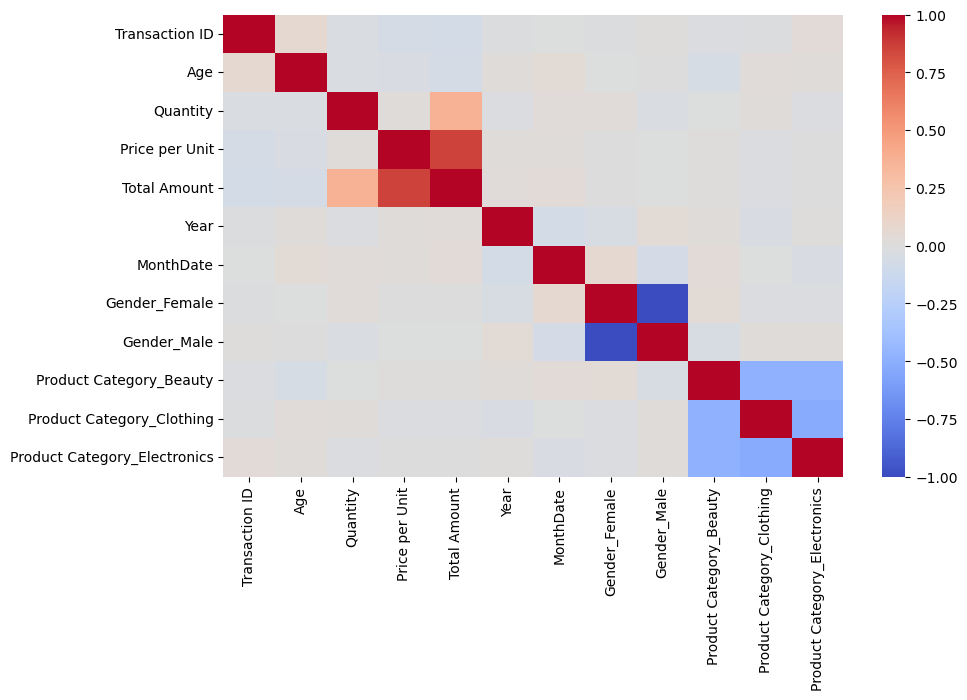

In [224]:
#Check the correlation between variables
df_dummies = pd.get_dummies(data=df,columns=['Gender','Product Category'])

plt.figure(figsize=(10,6))
sns.heatmap(df_dummies.corr(numeric_only=True),cmap='coolwarm')
plt.show()

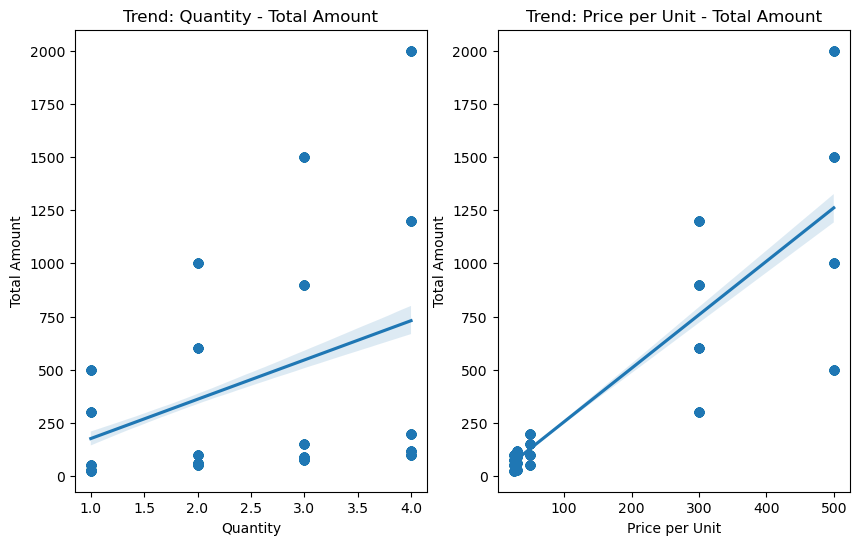

In [225]:
#Lets check the trend of these two variables with 'Total Amount'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.regplot(data=df,x='Quantity',y='Total Amount',ax=axes[0])
axes[0].set_title('Trend: Quantity - Total Amount')

sns.regplot(data=df, x='Price per Unit',y='Total Amount',ax=axes[1])
axes[1].set_title('Trend: Price per Unit - Total Amount')

plt.show()

In [ ]:
Recommendations:

1)Leverage social media campaigns or influencer endorsements focusing on modern male self-care routines.
2)Expand men’s fashion collections to include casual, athleisure, and formal wear.
3)Promote comfortable, elegant, and easy-to-wear fashion lines designed for senior women.
4)Use sports, tech, or business influencers to attract this demographic.
5)Target this age group with advertisements for user-friendly electronics (e.g., smart home devices, health gadgets).
6)Highlight convenience, safety, or lifestyle benefits in marketing messages.
7)Introduce age-specific skincare lines with clear messaging for mature skin.
8)Educate this segment via newsletters or blog posts about age-relevant beauty solutions.
9)Launch youth-focused fashion collections with trendy designs.
10)Promote on platforms popular among younger women (e.g., Instagram, YouTube influencers).